# Import Required Libraries

In [956]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt #Creates charts and visualizations to analyze
from matplotlib.ticker import FuncFormatter #displaying sales values in currency ($).

In [957]:
# Global E-Commerce dataset
ecommerce_df = pd.read_csv("../Data/global_ecommerce_sales.csv")

# E-Commerce Sales Transactions dataset
transaction_df = pd.read_csv("../Data/ecommerce_sales_transactions.csv")

# Initial Dataset Exploration

In [958]:
ecommerce_df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [959]:
transaction_df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


## Check Dataset Dimensions

- To verify the number of rows and columns before data cleaning and analysis. 
- This helps confirm that the datasets have been loaded successfully and provides an overview of their size.

In [960]:
print("ECommerce:", ecommerce_df.shape)
print("Transaction:", transaction_df.shape)

ECommerce: (2000, 15)
Transaction: (34500, 17)


## View Dataset Columns

- The column names are displayed to understand the structure of the datasets.
- Helps verify that all required fields are available for data cleaning, SQL analysis and visualization.

In [961]:
print(ecommerce_df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost', 'Profit', 'Payment_Method']


In [962]:
print(transaction_df.columns.tolist())

['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender']


## Inspect Dataset Information

- To review the data types, number of non-null values.
- This helps identify missing values and confirms that each column has the appropriate data type before data cleaning and analysis.

In [963]:
ecommerce_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   str    
 1   Order_Date        2000 non-null   str    
 2   Customer_Name     2000 non-null   str    
 3   Customer_Segment  2000 non-null   str    
 4   Country           2000 non-null   str    
 5   Region            2000 non-null   str    
 6   Product_Category  2000 non-null   str    
 7   Product_Name      2000 non-null   str    
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   str    
dtypes: float64(4), int64(2), str(9)
memory usage: 234.5 KB


In [964]:
transaction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  customer_gender

## Check for Missing Values

- To identify missing values in each column. 
- This step helps determine whether any columns require data cleaning or missing value process before further analysis.

In [965]:
ecommerce_df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

In [966]:
transaction_df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

## Check for Duplicate Records

- Duplicate records are checked in both datasets to ensure data quality and avoid inaccurate analysis. 
- Removing duplicate rows if present, helps maintain the reliability of sales calculations and business insights.

In [967]:
print("ECommerce:", ecommerce_df.duplicated().sum())
print("Transaction:", transaction_df.duplicated().sum())

ECommerce: 0
Transaction: 0


## Initial Dataset Exploration - Observations

The initial exploration was performed to understand the structure, size and quality of the datasets before applying any cleaning steps.

Key observations:

- Both datasets were successfully loaded and their dimensions were reviewed to understand the number of rows and columns.
- Column names were examined to identify available features and compare the structure of both datasets.
- Data types and non-null values were reviewed to identify columns requiring cleaning or transformation.
- Missing values were checked to understand data completeness.
- Duplicate records were identified to evaluate the overall data quality.
- Dataset differences were reviewed to determine which fields could support sales, customer, product and transaction analysis.

These initial checks provided a better understanding of the datasets and guided the data cleaning and preparation process.

# Data Cleaning and Standardization

## Compare Dataset Columns

- The columns from both datasets are compared side by side to understand the similarities and differences in their structures. 
- This comparison helps identify matching fields, missing values for data analysis.

In [968]:
comparison = pd.DataFrame({
    "ECommerce": pd.Series(ecommerce_df.columns),
    "Transaction": pd.Series(transaction_df.columns)
})

comparison

,ECommerce,Transaction
0,Order_ID,order_id
1,Order_Date,customer_id
2,Customer_Name,product_id
3,Customer_Segment,category
4,Country,price
5,Region,discount
6,Product_Category,quantity
7,Product_Name,payment_method
8,Quantity,order_date
9,Unit_Price,delivery_time_days


## Clean Column Names
- Standardize column names by converting them to lowercase
- removing extra spaces and replacing spaces with underscores.

- Manual code
    - ecommerce_df.columns = (ecommerce_df.columns.str.lower().str.strip().str.replace(" ", "_"))
    - transaction_df.columns = (transaction_df.columns.str.lower().str.strip().str.replace(" ", "_"))

In [969]:
# Function to clean column names 
def clean_column_names(df):
    df.columns = (df.columns.str.lower().str.strip().str.replace(" ", "_"))
    return df

ecommerce_df_df = clean_column_names(ecommerce_df)
transaction_df = clean_column_names(transaction_df)

# Display updated columns
print(ecommerce_df.columns)
print(transaction_df.columns)

Index(['order_id', 'order_date', 'customer_name', 'customer_segment',
       'country', 'region', 'product_category', 'product_name', 'quantity',
       'unit_price', 'discount_percent', 'total_sales', 'shipping_cost',
       'profit', 'payment_method'],
      dtype='str')
Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='str')


## Standardize column names 

- The column names are renamed to create consistency between datasets.
- This makes it easier to work with both datasets when creating the SQLite database and writing SQL queries.


In [970]:
# columns renames
ecommerce_df = ecommerce_df.rename(columns={
    "unit_price": "price",
    "discount_percent": "discount",
    "total_sales": "total_amount",
    "product_category": "category"
})


## Convert Date Columns to Datetime Format

- The `order_date` columns in both datasets are converted from their original format into datetime format. 
- This allows time-based analysis, filtering and feature creation.

In [971]:
# Convert order_date to datetime
ecommerce_df["order_date"] = pd.to_datetime(ecommerce_df["order_date"])
transaction_df["order_date"] = pd.to_datetime(transaction_df["order_date"])

# Verify the changes
print(ecommerce_df["order_date"].dtype)
print(transaction_df["order_date"].dtype)

datetime64[us]
datetime64[us]


## Standardize Payment Method Names

- Payment method values are standardized to maintain consistency across datasets.
- The abbreviation `COD` is replaced with `Cash on Delivery` so that similar payment methods use the same naming convention during analysis and comparison.

In [972]:
transaction_df["payment_method"] = transaction_df["payment_method"].replace({"COD": "Cash on Delivery"})

# Verify the changes
print(transaction_df["payment_method"].unique())

<StringArray>
['Credit Card', 'UPI', 'Cash on Delivery', 'PayPal', 'Debit Card', 'Wallet']
Length: 6, dtype: str


## Data Cleaning Observations

During the data cleaning process, the following observations were identified:

- Dataset structures were reviewed by comparing columns from both datasets.
- Column names were standardized to improve consistency and make analysis easier.
- Date columns were converted into datetime format to support time-based analysis.
- Payment method names were standardized (for example, `COD` was changed to `Cash on Delivery`) for consistency.

These cleaning steps helped prepare the datasets for SQL analysis and visualization.

# Data Quality Checks After Cleaning

## Check for Missing Values After Cleaning

- Missing values are checked again after data preparation to confirm the quality of the cleaned datasets. 
- This step ensures that important fields required for analysis and visualization do not contain incomplete records.

In [973]:
# Check for missing values 
print("Global Ecommerce Dataset")
print(ecommerce_df.isnull().sum())

print("\nTransaction Dataset")
print(transaction_df.isnull().sum())

Global Ecommerce Dataset
order_id            0
order_date          0
customer_name       0
customer_segment    0
country             0
region              0
category            0
product_name        0
quantity            0
price               0
discount            0
total_amount        0
shipping_cost       0
profit              0
payment_method      0
dtype: int64

Transaction Dataset
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64


## Check for Duplicate Records After Cleaning

- Duplicate records are checked after the data cleaning process to ensure that the datasets do not contain repeated entries. 

In [974]:
# Check for duplicate rows 
print("Ecommerce Dataset:", ecommerce_df.duplicated().sum())

print("Transaction Dataset:", transaction_df.duplicated().sum())

Ecommerce Dataset: 0
Transaction Dataset: 0


## Check for Negative Values

- Negative values are checked in important numerical columns to identify any invalid or unexpected records. 
- Columns such as quantity, price, discount, sales amount, shipping cost, and profit are reviewed to ensure data quality before performing analysis.

In [975]:
# Checking for negative values in key numeric columns 
(ecommerce_df[["quantity", "price", "discount",
            "total_amount", "shipping_cost", "profit"]] < 0).sum()

quantity           0
price              0
discount           0
total_amount       0
shipping_cost      0
profit           272
dtype: int64

In [976]:
(transaction_df[["price", "discount", "quantity","total_amount", "shipping_cost","profit_margin"]] < 0).sum()

price               0
discount            0
quantity            0
total_amount        0
shipping_cost       0
profit_margin    6104
dtype: int64

## Data Quality Checks After Cleaning - Observations

After completing the data cleaning process, additional quality checks were performed to confirm that the datasets were ready for analysis.

Key observations:

- Missing values were reviewed after cleaning to ensure important columns contained complete data.
- Duplicate records were checked again to confirm that repeated entries were not affecting analysis results.
- Date columns were verified to ensure they were correctly converted into datetime format.
- Numerical columns were checked for invalid negative values to identify potential data issues.
- Categorical values such as payment methods and product categories were reviewed for consistency.

These checks confirmed that the cleaned datasets were reliable and ready for SQL analysis and visualization.

# Exploratory Data Analysis (EDA)

## Generate Descriptive Statistics

- Descriptive statistics are generated to understand the distribution and characteristics of numerical columns in both datasets.
- This includes measures such as count, mean, standard deviation, minimum, maximum and quartile values, which help identify patterns and potential outliers.

In [977]:
ecommerce_df.describe()
transaction_df.describe()

,price,discount,quantity,order_date,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,2024-09-13 13:39:17.843478,4.814203,170.008494,6.152120,28.116505,43.474377
min,1.010000,0.000000,1.000000,2023-09-12 00:00:00,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,2024-03-14 00:00:00,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,2024-09-16 00:00:00,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,2025-03-17 00:00:00,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,2025-09-11 00:00:00,13.000000,12931.800000,15.650000,1536.170000,69.000000
std,195.620477,0.069894,0.932270,NaN,1.242141,357.503014,2.389539,53.352947,14.980682


## Check Unique Values in Categorical Columns

- The unique values in the `payment_method` column are reviewed for both datasets to identify differences in categories and ensure consistency before analysis. 
- This helps understand the available payment options and supports accurate comparison between datasets.

In [978]:
#checking unique values
print("Ecommerce Dataset Payment Methods:")
print(ecommerce_df["payment_method"].unique())

print("\nTransaction Dataset Payment Methods:")
print(transaction_df["payment_method"].unique())

Ecommerce Dataset Payment Methods:
<StringArray>
['Cash on Delivery', 'Credit Card', 'PayPal', 'Bank Transfer']
Length: 4, dtype: str

Transaction Dataset Payment Methods:
<StringArray>
['Credit Card', 'UPI', 'Cash on Delivery', 'PayPal', 'Debit Card', 'Wallet']
Length: 6, dtype: str


## Check Unique Product Categories

- The unique product categories in both datasets are reviewed to understand the category structure and identify differences between datasets.
- This helps verify the available categories and ensures accurate analysis during sales and product performance evaluation.

In [979]:
print(ecommerce_df["category"].unique())
print(transaction_df["category"].unique())

<StringArray>
['Technology', 'Office Supplies', 'Furniture', 'Clothing & Accessories']
Length: 4, dtype: str
<StringArray>
['Home', 'Grocery', 'Electronics', 'Beauty', 'Fashion', 'Toys', 'Sports']
Length: 7, dtype: str


## Exploratory Data Analysis (EDA) - Observations

Exploratory Data Analysis was performed to understand patterns, trends and relationships within the cleaned datasets before conducting SQL analysis and creating visualizations.

Key observations:

- Descriptive statistics were reviewed to understand the distribution of numerical features such as price, quantity, sales, shipping cost, profit and delivery time.
- Product categories, payment methods and other categorical variables were analyzed to understand the available business segments.
- Sales and profit values were examined to identify high-performing and low-performing areas.
- Customer and product-related attributes were reviewed to understand purchasing behavior and business performance.
- Numerical features were checked for unusual values or potential outliers that could affect analysis results.
- The EDA process helped identify important factors for further analysis, including product performance, customer sales contribution, profitability, and purchasing trends.

These findings guided the SQL queries and visualizations used to generate business insights.

# Data Transformation

## Create Date Features

New date-based features are created from the `order_date` column to support deeper analysis of sales trends and customer purchasing patterns.

The following features are added:
- **order_year** – Extracts the year from the order date to analyze yearly performance.
- **order_month** – Extracts the month name to identify monthly purchasing patterns.
- **order_day** – Extracts the day of the month for additional date-based analysis.

Creating these features makes it easier to perform time-based analysis and generate meaningful business insights.visualizations.

### manual code
    - ecommerce_df["order_year"] = ecommerce_df["order_date"].dt.year
    - ecommerce_df["order_month"] = ecommerce_df["order_date"].dt.month_name()
    - ecommerce_df["order_day"] = ecommerce_df["order_date"].dt.day

    - transaction_df["order_year"] = transaction_df["order_date"].dt.year
    - transaction_df["order_month"] = transaction_df["order_date"].dt.month_name()
    - transaction_df["order_day"] = transaction_df["order_date"].dt.day


In [980]:
def create_date_features(df):
    df["order_year"] = df["order_date"].dt.year
    df["order_month"] = df["order_date"].dt.month_name()
    df["order_day"] = df["order_date"].dt.day
    
    return df

ecommerce_df_df = create_date_features(ecommerce_df)
transaction_df = create_date_features(transaction_df)

ecommerce_df.head()

,order_id,order_date,customer_name,customer_segment,country,region,category,product_name,quantity,price,discount,total_amount,shipping_cost,profit,payment_method,order_year,order_month,order_day
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery,2023,January,2
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery,2023,January,2
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card,2023,January,3
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal,2023,January,3
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,2023,January,5


In [981]:

transaction_df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,order_year,order_month,order_day
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,2023,December,23
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,2025,April,3
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,2024,October,8
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,2024,September,14
4,O100004,C15226,P228063,Home,16.33,0.15,1,Cash on Delivery,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,2024,December,21


## Standardize Discount Values-Convert percentage to decimal

The `discount` column is converted from percentage format into decimal format to maintain consistency with the transaction dataset.

For example:
- `10` represents a 10% discount.
- After conversion, it becomes `0.10`.

This standardization makes discount calculations more accurate and allows consistent analysis across datasets.

In [982]:
ecommerce_df["discount"] = ecommerce_df["discount"] / 100

## Calculate Discount Amount

A reusable function is created to calculate the actual discount amount for each transaction.

The `discount_amount` feature is calculated using:

- Product price
- Quantity purchased
- Discount value
Formula:
**Discount Amount = Price × Quantity × Discount**


In [983]:
def calculate_discount_amount(df, price_col, quantity_col, discount_col):
    
    df["discount_amount"] = (
        df[price_col] *
        df[quantity_col] *
        df[discount_col]
    )
    
    return df

In [984]:
ecommerce_df = calculate_discount_amount(
    ecommerce_df,
    "price",
    "quantity",
    "discount"
)
ecommerce_df.head()


,order_id,order_date,customer_name,customer_segment,country,region,category,product_name,quantity,price,discount,total_amount,shipping_cost,profit,payment_method,order_year,order_month,order_day,discount_amount
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0.00,298.29,9.31,124.92,Cash on Delivery,2023,January,2,0.000
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,0.20,313.38,14.31,83.62,Cash on Delivery,2023,January,2,78.344
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0.00,21.48,8.12,3.69,Credit Card,2023,January,3,0.000
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,0.15,105.16,10.79,26.32,PayPal,2023,January,3,18.558
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,0.20,1058.14,11.09,253.44,Credit Card,2023,January,5,264.536


In [985]:

transaction_df = calculate_discount_amount(
    transaction_df,
    "price",
    "quantity",
    "discount"
)
transaction_df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,...,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,order_year,order_month,order_day,discount_amount
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,...,No,139.47,7.88,31.17,60,Female,2023,December,23,24.6120
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,...,No,24.73,4.60,-2.62,37,Male,2025,April,3,0.0000
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,...,No,166.80,6.58,13.44,34,Male,2024,October,8,8.7790
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,...,No,63.67,5.50,2.14,21,Female,2024,September,14,0.0000
4,O100004,C15226,P228063,Home,16.33,0.15,1,Cash on Delivery,2024-12-21,6,...,No,13.88,2.74,1.15,39,Male,2024,December,21,2.4495


##  Create Loss Flag

A new feature called `loss_flag` is created to identify transactions where the business generated a loss.

- If `profit` is less than 0, the value is marked as **True** (loss).
- If `profit` is greater than or equal to 0, the value is marked as **False** (profitable transaction).

This feature helps analyze loss-making transactions and understand factors that may impact profitability.

In [986]:
ecommerce_df["loss_flag"] = ecommerce_df["profit"] < 0
ecommerce_df.head()

,order_id,order_date,customer_name,customer_segment,country,region,category,product_name,quantity,price,discount,total_amount,shipping_cost,profit,payment_method,order_year,order_month,order_day,discount_amount,loss_flag
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0.00,298.29,9.31,124.92,Cash on Delivery,2023,January,2,0.000,False
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,0.20,313.38,14.31,83.62,Cash on Delivery,2023,January,2,78.344,False
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0.00,21.48,8.12,3.69,Credit Card,2023,January,3,0.000,False
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,0.15,105.16,10.79,26.32,PayPal,2023,January,3,18.558,False
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,0.20,1058.14,11.09,253.44,Credit Card,2023,January,5,264.536,False


In [987]:
transaction_df["loss_flag"] = transaction_df["profit_margin"] < 0
transaction_df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,...,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,order_year,order_month,order_day,discount_amount,loss_flag
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,...,139.47,7.88,31.17,60,Female,2023,December,23,24.6120,False
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,...,24.73,4.60,-2.62,37,Male,2025,April,3,0.0000,True
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,...,166.80,6.58,13.44,34,Male,2024,October,8,8.7790,False
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,...,63.67,5.50,2.14,21,Female,2024,September,14,0.0000,False
4,O100004,C15226,P228063,Home,16.33,0.15,1,Cash on Delivery,2024-12-21,6,...,13.88,2.74,1.15,39,Male,2024,December,21,2.4495,False


## Data transfermation - Observations
Key observations:

- Date-based features such as `order_year`, `order_month`, and `order_day` were created from the `order_date` column to support time-based analysis.
- Discount values were standardized into decimal format to maintain consistency between datasets.
- A `discount_amount` feature was calculated to measure the actual discount value applied to each transaction.
- A `loss_flag` feature was created to identify transactions where the profit value was negative.
- These newly created features improve the ability to analyze sales patterns, discount impact, and profitability.

The engineered features provide additional insights and support SQL queries and visualizations in later stages of the project.

# SQLite Database

- This section creates a SQLite database based on the Entity Relationship Diagram (ERD).
- The cleaned datasets are loaded into relational tables so they can be queried using SQL.


The following tables are created:

- **global_products**: 
- **global_sales**:
- **customers**:
- **transaction_sales**:
- **transaction_products**:

The data is loaded into SQLite using `to_sql()` to support SQL queries and business analysis. Existing tables are replaced to ensure the database contains the latest cleaned data.

In [988]:
conn = sqlite3.connect('../data/ecommerce_analysis.db')

global_products_df = (ecommerce_df[["product_name", "category"]].drop_duplicates().reset_index(drop=True))

global_sales_df = (ecommerce_df[["order_id","product_name","order_date","customer_name","customer_segment","country",
"region","quantity","price","discount","total_amount","shipping_cost","profit","payment_method",]].drop_duplicates().reset_index(drop=True))


customers_df = (transaction_df[["customer_id","customer_age","customer_gender",]].drop_duplicates().reset_index(drop=True))

transaction_sales_df = transaction_df[["order_id","customer_id","product_id","order_date","category","price","discount",
"quantity","payment_method","delivery_time_days","region","returned","total_amount","shipping_cost","profit_margin",]].copy()

transaction_products_df = (transaction_df[["product_id","category",]].drop_duplicates().reset_index(drop=True))


global_products_df.to_sql('global_products', conn, if_exists='replace', index=False)
global_sales_df.to_sql('global_sales', conn, if_exists='replace', index=False)
customers_df.to_sql('customers', conn, if_exists='replace', index=False)
transaction_sales_df.to_sql('transaction_sales', conn, if_exists='replace', index=False)
transaction_products_df.to_sql('transaction_products', conn, if_exists='replace', index=False)
conn.commit()

# SQL Queries and Analysis

The following SQL queries were performed on the SQLite database to analyze sales performance, profitability, customer behavior and product performance. 

### 1)Total Sales and Profit by Product Category

In [989]:
query1 = """
select
    category,
    count(*) as total_orders,
    round(sum(total_amount),2) as total_sales,
    round(sum(profit),2) as total_profit
from global_sales gs
join global_products gp
on gs.product_name = gp.product_name
group by category
order by total_sales desc;
""" 

category_sales = pd.read_sql(query1, conn)
category_sales

,category,total_orders,total_sales,total_profit
0,Furniture,507,256274.68,81171.57
1,Technology,567,139518.22,48268.65
2,Clothing & Accessories,413,69375.63,26112.94
3,Office Supplies,513,19390.81,3319.16


### 2) Top 10 Countries by total Sales

In [990]:
query2 = """
select
    country,
    round(sum(total_amount),2) as total_sales
from global_sales
group by country
order by total_sales desc
limit 10;
"""

country_sales = pd.read_sql(query2, conn)
country_sales

,country,total_sales
0,Mexico,47217.30
1,Canada,45326.55
2,United States,41332.53
3,Japan,30950.19
4,United Kingdom,30185.46
5,Germany,28989.73
6,China,28322.85
7,Italy,27484.38
8,France,26616.81
9,Australia,25287.72


### 3) Average Profit Margin by Customer Gender

In [991]:
query3 = """
select
    customer_gender,
    round(avg(profit_margin),2) as average_profit_margin
from transaction_sales ts
join customers c
on ts.customer_id = c.customer_id
group by customer_gender;
"""

gender_profit = pd.read_sql(query3, conn)
gender_profit

,customer_gender,average_profit_margin
0,Female,28.23
1,Male,28.13
2,Other,28.70


### 4) Average Delivery Time by Payment Method

In [992]:
query4 = """
select
    payment_method,
    round(avg(delivery_time_days),2) as average_delivery_days
from transaction_sales
group by payment_method
order by average_delivery_days;
"""

delivery_time = pd.read_sql(query4, conn)
delivery_time

,payment_method,average_delivery_days
0,PayPal,4.77
1,UPI,4.80
2,Debit Card,4.81
3,Cash on Delivery,4.82
4,Credit Card,4.83
5,Wallet,4.85


### 5) Products with Above-Average Profit

In [993]:
query5 = """
select
    product_name,
    profit
from global_sales
where profit >
(
    select avg(profit)
    from global_sales
)
order by profit desc
limit 10;
"""

top_profit = pd.read_sql(query5, conn)
top_profit

,product_name,profit
0,Corner L-Shaped Desk,1373.63
1,Corner L-Shaped Desk,1370.08
2,Ergonomic Office Chair,1189.79
3,Mesh Back Task Chair,1116.45
4,Ergonomic Office Chair,1115.05
5,Ergonomic Office Chair,1054.26
6,Corner L-Shaped Desk,1017.49
7,Mesh Back Task Chair,992.84
8,Standing Desk Converter,874.37
9,Standing Desk Converter,860.28


### 6) Top 10 customers by total sales

In [994]:
query6 = """
SELECT
    customer_name,
    ROUND(SUM(total_amount), 2) AS total_sales
FROM global_sales
GROUP BY customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query6, conn)
top_customers

,customer_name,total_sales
0,Priya Jackson,3836.46
1,Hanna Jones,3813.98
2,Sarah Chen,3184.56
3,Li Laurent,3007.62
4,Nadia Wang,2958.97
5,Priya Oliveira,2901.11
6,Felix Thompson,2835.36
7,Linda Weber,2762.40
8,Karen Sato,2738.18
9,Lucas Nilsson,2734.69


### 7) Most frequently ordered products.

In [995]:
query7 = """
SELECT
    product_name,
    SUM(quantity) AS total_quantity_ordered
FROM global_sales
GROUP BY product_name
ORDER BY total_quantity_ordered DESC
LIMIT 5;
"""

top_products = pd.read_sql(query7, conn)
top_products

,product_name,total_quantity_ordered
0,Wireless Ergonomic Mouse,238
1,Mechanical Gaming Keyboard,227
2,Folding Table Portable,226
3,Tablet Stand Holder,225
4,Smart LED Desk Lamp,222


# Visualization 

### 1) Total Sales by Product Category

This chart compares the total sales generated by each product category.

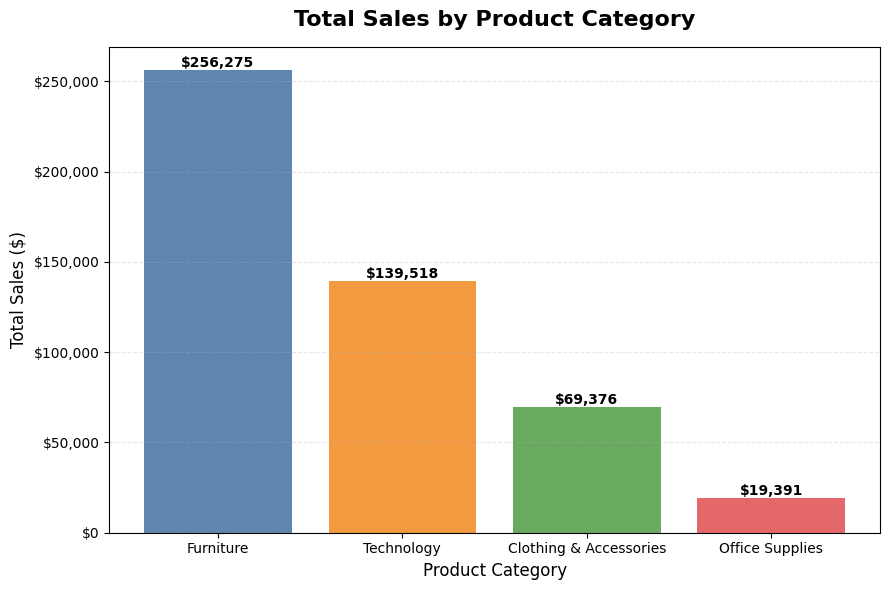

In [996]:
plt.figure(figsize=(9,6))
bars = plt.bar(
    category_sales["category"],
    category_sales["total_sales"],
    color=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"],
    alpha=0.9)
# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.title(
    "Total Sales by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig('..//Plots/Total_sales_by_product_category.png')
plt.show()

### Insights
- The highest-performing categories generate a larger share of overall revenue and may represent key areas for business focus.
- Lower-performing categories may require further investigation, such as reviewing pricing, discounts, customer preferences or product availability.
- Understanding category-level sales performance helps identify opportunities for improving marketing strategies and inventory planning.


### 2) Top 10 Countries by Sales

This chart highlights the countries with the highest total sales.

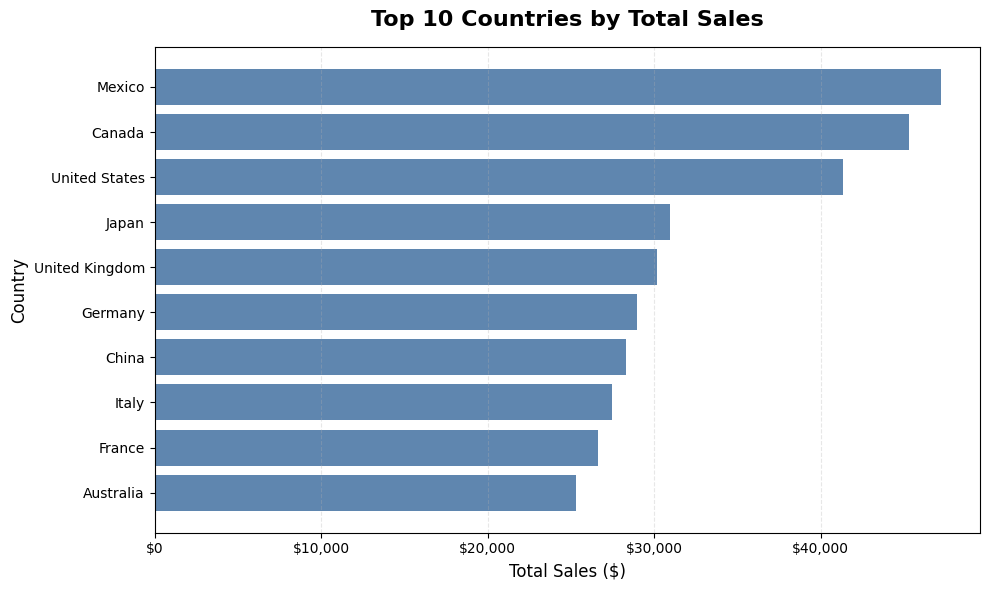

In [997]:
plt.figure(figsize=(10,6))
bars = plt.barh(
    country_sales["country"],
    country_sales["total_sales"],
    color="#4E79A7",
    alpha=0.9
)
# Format x-axis as currency
plt.gca().xaxis.set_major_formatter(
FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.title(
    "Top 10 Countries by Total Sales",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("Total Sales ($)", fontsize=12)
plt.ylabel("Country", fontsize=12)
# Highest sales at the top
plt.gca().invert_yaxis()
# Light grid
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig('..//Plots/Top_10_countries_by_total_sales.png')
plt.show()

### Insight

- Sales contribution differs across countries, showing variations in customer demand and market performance.
- The highest-ranked countries represent the strongest revenue-generating markets and may provide opportunities for targeted marketing and business expansion.
- A country-level sales comparison helps identify important markets and supports data-driven decisions for sales strategies.


### 3) Relationship Between Price and Profit

This scatter plot shows the relationship between product price and profit. It helps determine whether higher priced products tend to generate higher profits.

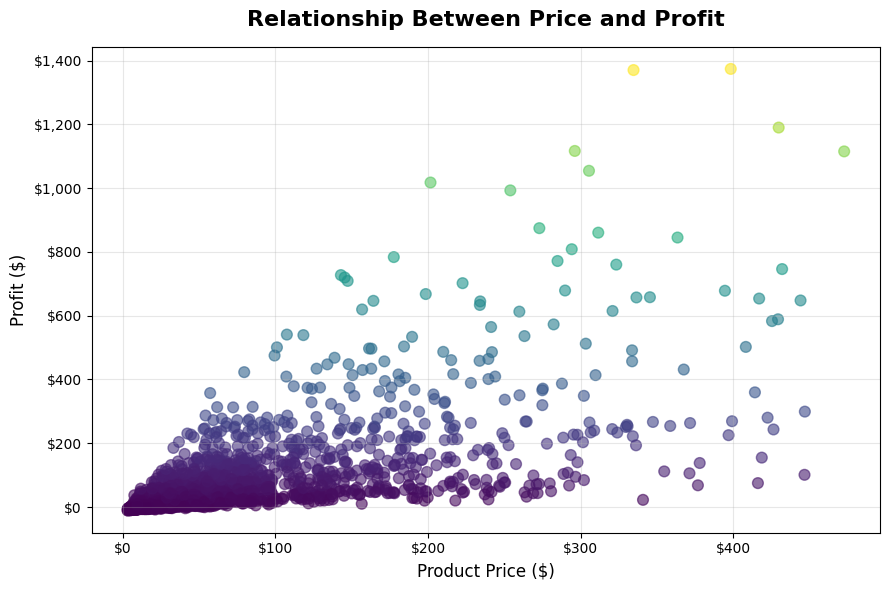

In [998]:
plt.figure(figsize=(9,6))
# Scatter plot
plt.scatter(
    ecommerce_df["price"],
    ecommerce_df["profit"],
    alpha=0.6,
    c=ecommerce_df["profit"],
    cmap="viridis",
    s=60)
# Currency format
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'${y:,.0f}'))
plt.title(
    "Relationship Between Price and Profit",
    fontsize=16,
    fontweight="bold",
    pad=15)
plt.xlabel("Product Price ($)", fontsize=12)
plt.ylabel("Profit ($)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('..//Plots/Relationship_between_price_and_profit.png')
plt.show()

### Insights

- The scatter plot shows a positive relationship between price and profit.
- Higher-priced products generally generate higher profits, although some lower-priced products are also profitable.
- This suggests that pricing is an important factor influencing profitability, but it is not the only factor.

### 4) Top 10 customers by total sales

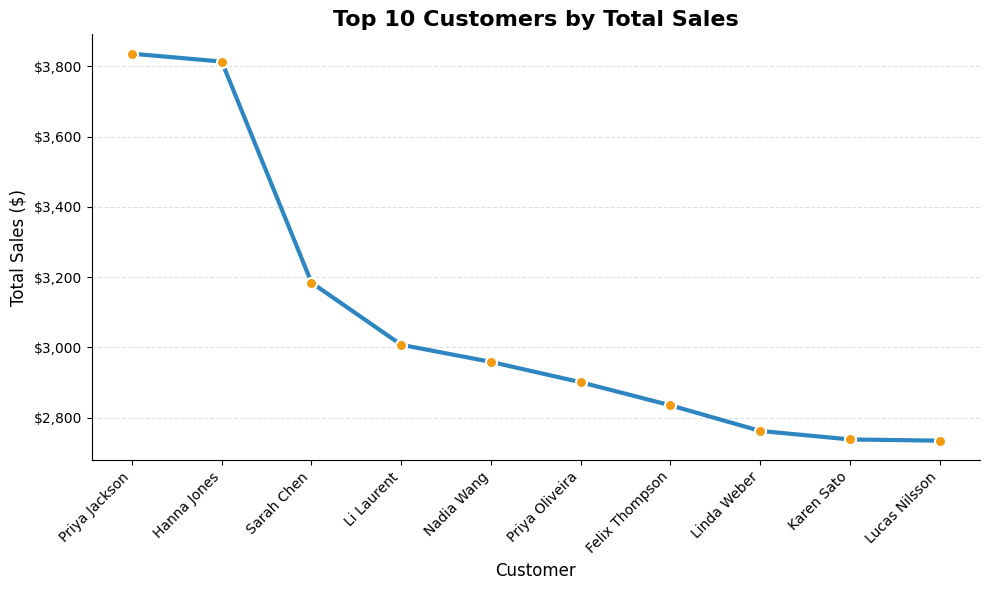

In [999]:

plt.figure(figsize=(10,6))
plt.plot(
    top_customers["customer_name"],
    top_customers["total_sales"],
    color="#2E86C1",          # Blue line
    marker="o",
    markersize=8,
    markerfacecolor="#F39C12",
    markeredgecolor="white",
    markeredgewidth=1.5,
    linewidth=3)
# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(
FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.title("Top 10 Customers by Total Sales", fontsize=16, weight="bold")
plt.xlabel("Customer", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.xticks(rotation=45, ha="right")
# Light grid
plt.grid(axis="y", linestyle="--", alpha=0.4)
# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig('..//Plots/Top_10_customers_by_total_sales.png')
plt.show()

### Insights

- The top 10 customers generated the highest total sales, highlighting them as the business's most valuable customers.
- Retaining these high-value customers through loyalty programs, personalized offers and excellent customer service can help increase repeat purchases.
- Analyzing the purchasing patterns of these customers can provide insights for targeted marketing strategies and revenue growth.

### 5) Most Frequently Ordered Products

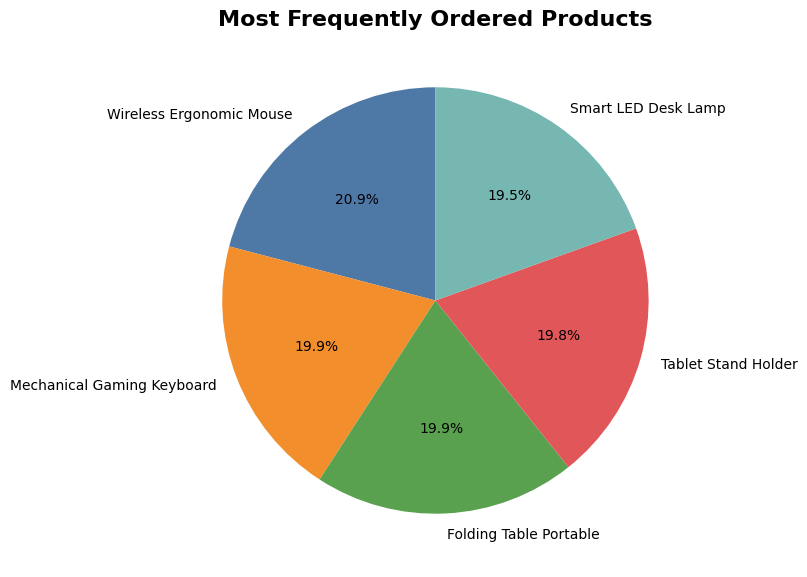

In [1000]:
plt.figure(figsize=(8,8))
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2"]
plt.pie(
    top_products["total_quantity_ordered"],
    labels=top_products["product_name"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 10})
plt.title(
    "Most Frequently Ordered Products",
    fontsize=16,
    weight="bold")
plt.tight_layout()
plt.savefig('..//Plots/Most_frequently_ordered_products.png')
plt.show()

### Insights

- The pie chart shows the distribution of order quantities among the top five most frequently ordered products.
- The largest slice represents the product with the highest demand, making it the best-selling product by quantity.
- The business can prioritize inventory planning and promotional strategies for these high-demand products to improve customer satisfaction and maintain sales growth.